# FFT aplicada a audio — IMT2220

Flujo general:

```
Cargar audio → Graficar → FFT → Graficar espectro → Filtrar → Graficar → IFFT → Guardar
```

Aplicaremos **tres filtros distintos** siguiendo siempre el mismo esquema.

1. **Pasa-bajos**: elimina las frecuencias altas (apaga el sonido)
2. **Pasa-altos**: elimina las frecuencias bajas (quita la voz y el bajo)
3. **Eliminar bandas dominantes**: busca la frecuencia con mayor magnitud, la elimina, y repite

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile

---
## Cargar y preparar el audio

In [2]:
ARCHIVO = 'piano-sample.wav'

sample_rate, audio_raw = wavfile.read(ARCHIVO)

print(f"Sample rate : {sample_rate} Hz")
print(f"Forma       : {audio_raw.shape}")
print(f"Duración    : {audio_raw.shape[0] / sample_rate:.2f} s")

Sample rate : 48000 Hz
Forma       : (960000, 2)
Duración    : 20.00 s


In [3]:
# Estéreo → Mono: nos quedamos con el canal izquierdo
if audio_raw.ndim == 2:
    audio = audio_raw[:, 0].astype(float)
else:
    audio = audio_raw.astype(float)

# Normalizar a [-1, 1] según el rango del tipo de dato (ej: int16 → dividir por 32767)
audio = audio / np.iinfo(audio_raw.dtype).max

N = len(audio)
duracion = N / sample_rate
tiempo = np.linspace(0, duracion, N, endpoint=False)

print(f"N = {N} muestras")

N = 960000 muestras


### Audio en el tiempo

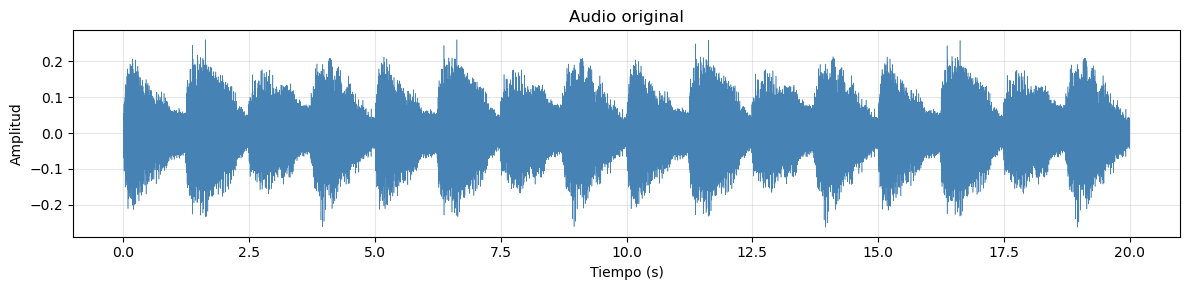

In [4]:
plt.figure(figsize=(12, 3))
plt.plot(tiempo, audio, linewidth=0.4, color='steelblue')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.title('Audio original')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### FFT del audio original

Calculamos la FFT una sola vez y la guardamos.  
Los tres filtros parten siempre desde `fft_audio` original.

In [5]:
# rfft: FFT para señales reales (solo frecuencias positivas)
fft_audio = np.fft.rfft(audio)

# Frecuencias correspondientes a cada coeficiente
freqs = np.fft.rfftfreq(N, d=1/sample_rate)

# Magnitud de cada coeficiente
magnitud = np.abs(fft_audio)

print(f"Frecuencia máxima: {freqs[-1]:.0f} Hz")

Frecuencia máxima: 24000 Hz


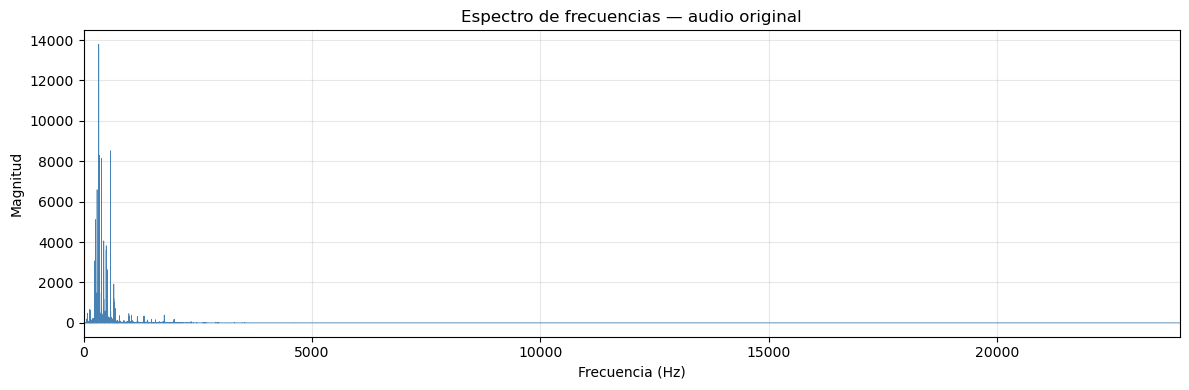

In [6]:
plt.figure(figsize=(12, 4))
plt.plot(freqs, magnitud, linewidth=0.5, color='steelblue')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Magnitud')
plt.title('Espectro de frecuencias — audio original')
plt.xlim(0, freqs[-1])  # frecuencia de Nyquist = sample_rate / 2
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Frecuencia máxima relevante (magnitud > 1000): 663.4 Hz


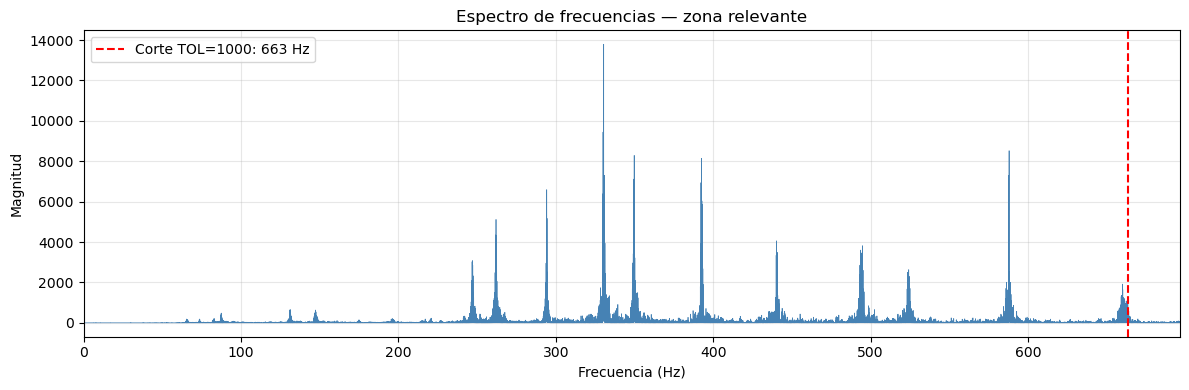

In [7]:
# Buscar hasta qué frecuencia hay contenido relevante
# TOL: magnitud mínima para considerar que una frecuencia "aporta" algo
TOL = 1000

# Última frecuencia cuya magnitud supera TOL
indices_relevantes = np.where(magnitud > TOL)[0]
f_relevante = freqs[indices_relevantes[-1]]
print(f"Frecuencia máxima relevante (magnitud > {TOL}): {f_relevante:.1f} Hz")

plt.figure(figsize=(12, 4))
plt.plot(freqs, magnitud, linewidth=0.5, color='steelblue')
plt.axvline(f_relevante, color='red', linestyle='--', label=f'Corte TOL={TOL}: {f_relevante:.0f} Hz')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Magnitud')
plt.title('Espectro de frecuencias — zona relevante')
plt.xlim(0, f_relevante * 1.05)  # un poco de margen
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

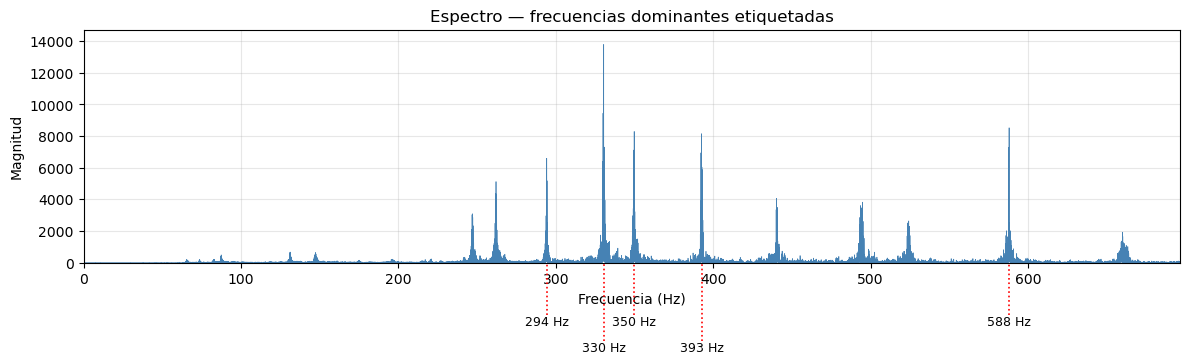

In [45]:
# Encontrar las frecuencias dominantes con el mismo método iterativo
N_ETIQUETAS = 5    # cuántas frecuencias etiquetar
ANCHO_ETQ   = 10   # Hz a cada lado para no repetir el mismo máximo

mag_temp = magnitud.copy()
etiquetas_f   = []
etiquetas_mag = []
for _ in range(N_ETIQUETAS):
    idx = np.argmax(mag_temp)
    etiquetas_f.append(freqs[idx])
    etiquetas_mag.append(magnitud[idx])
    mag_temp[np.abs(freqs - freqs[idx]) < ANCHO_ETQ] = 0

# Ordenar por frecuencia (izquierda a derecha) antes de asignar niveles
# así etiquetas vecinas en el eje X siempre quedan a distinta altura
orden = np.argsort(etiquetas_f)
etiquetas_f   = [etiquetas_f[i]   for i in orden]
etiquetas_mag = [etiquetas_mag[i] for i in orden]

paso = magnitud.max() * 0.12
niveles = [2*paso, 3*paso]  # se repiten cíclicamente

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(freqs, magnitud, linewidth=0.5, color='steelblue')

for i, (f, m) in enumerate(zip(etiquetas_f, etiquetas_mag)):
    prof = niveles[i % len(niveles)]
    ax.plot([f, f], [-prof, 0], color='red', linestyle=':', linewidth=1.2, clip_on=False)
    ax.text(f, -prof, f'{f:.0f} Hz',
            ha='center', va='top', fontsize=9, clip_on=False)

ax.set_xlabel('Frecuencia (Hz)')
ax.set_ylabel('Magnitud')
ax.set_title('Espectro — frecuencias dominantes etiquetadas')
ax.set_xlim(0, f_relevante * 1.05)
ax.set_ylim(0)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## Filtro 1: Pasa-bajos

Ponemos en cero todos los coeficientes con frecuencia **mayor** a `f_corte`.  
Solo sobreviven las frecuencias bajas.

In [35]:
f_corte_bajo = 1000  # Hz

fft_bajo = fft_audio.copy()
fft_bajo[freqs > f_corte_bajo] = 0

print(f"Coeficientes conservados : {np.sum(freqs <= f_corte_bajo)}")
print(f"Coeficientes eliminados  : {np.sum(freqs > f_corte_bajo)}")

Coeficientes conservados : 20001
Coeficientes eliminados  : 460000


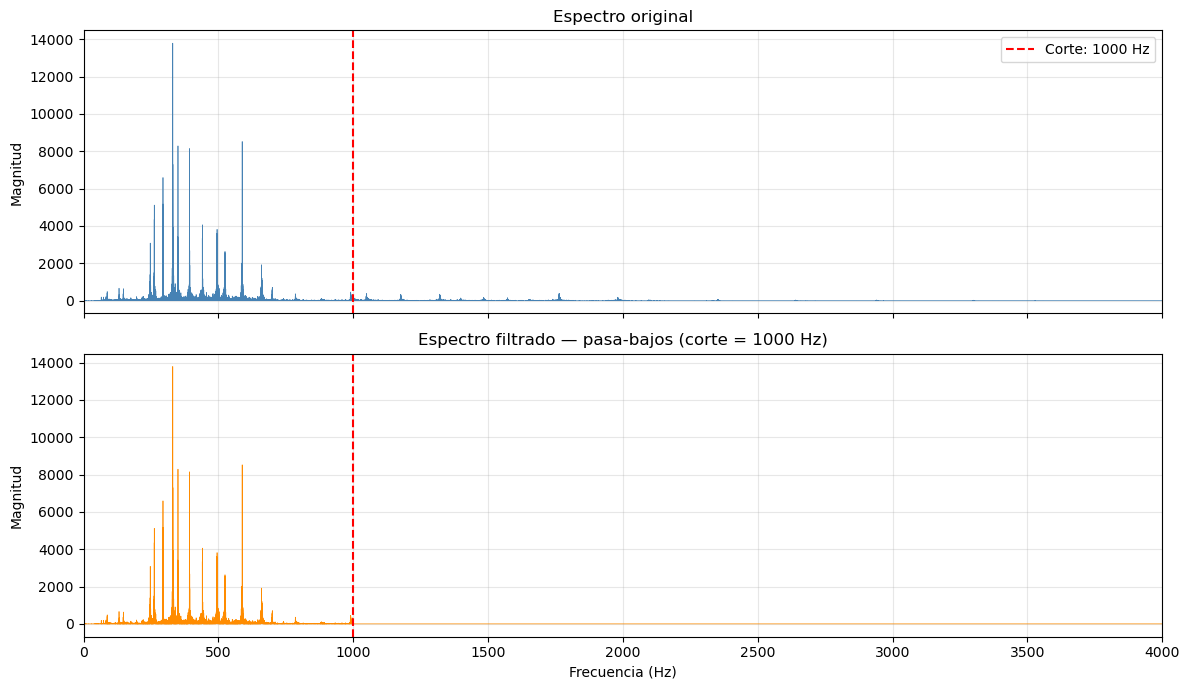

In [36]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

axes[0].plot(freqs, magnitud, linewidth=0.5, color='steelblue')
axes[0].axvline(f_corte_bajo, color='red', linestyle='--', label=f'Corte: {f_corte_bajo} Hz')
axes[0].set_ylabel('Magnitud')
axes[0].set_title('Espectro original')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(freqs, np.abs(fft_bajo), linewidth=0.5, color='darkorange')
axes[1].axvline(f_corte_bajo, color='red', linestyle='--')
axes[1].set_xlabel('Frecuencia (Hz)')
axes[1].set_ylabel('Magnitud')
axes[1].set_title(f'Espectro filtrado — pasa-bajos (corte = {f_corte_bajo} Hz)')
axes[1].grid(True, alpha=0.3)

plt.xlim(0, 4000)
plt.tight_layout()
plt.show()

In [37]:
# IFFT: reconstruimos la señal de audio a partir de los coeficientes filtrados
audio_bajo = np.fft.irfft(fft_bajo, n=N)

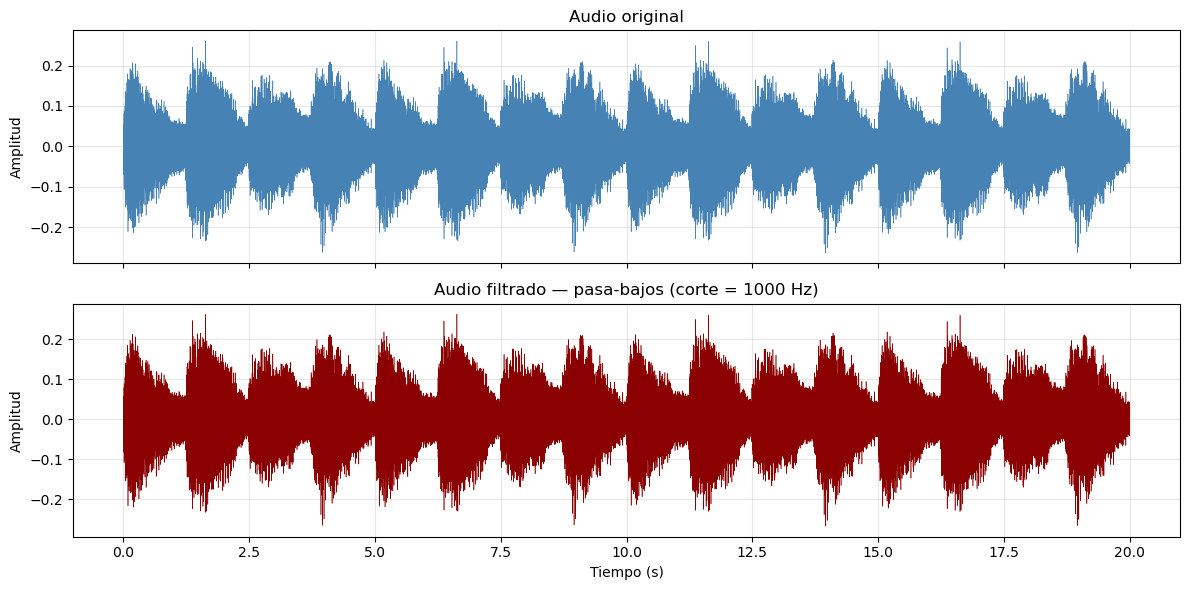

In [47]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

axes[0].plot(tiempo, audio, linewidth=0.4, color='steelblue')
axes[0].set_ylabel('Amplitud')
axes[0].set_title('Audio original')
axes[0].grid(True, alpha=0.3)

axes[1].plot(tiempo, audio_bajo, linewidth=0.4, color='darkred')
axes[1].set_xlabel('Tiempo (s)')
axes[1].set_ylabel('Amplitud')
axes[1].set_title(f'Audio filtrado — pasa-bajos (corte = {f_corte_bajo} Hz)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [39]:
wavfile.write('audio_pasa_bajos.wav', sample_rate,
              np.int16(np.clip(audio_bajo, -1, 1) * 32767))
print("Guardado: audio_pasa_bajos.wav")

Guardado: audio_pasa_bajos.wav


---
## Filtro 2: Pasa-altos

Ponemos en cero todos los coeficientes con frecuencia **menor** a `f_corte`.  
Solo sobreviven las frecuencias altas.

In [40]:
f_corte_alto = 1000  # Hz

fft_alto = fft_audio.copy()
fft_alto[freqs < f_corte_alto] = 0

print(f"Coeficientes conservados : {np.sum(freqs >= f_corte_alto)}")
print(f"Coeficientes eliminados  : {np.sum(freqs < f_corte_alto)}")

Coeficientes conservados : 460001
Coeficientes eliminados  : 20000


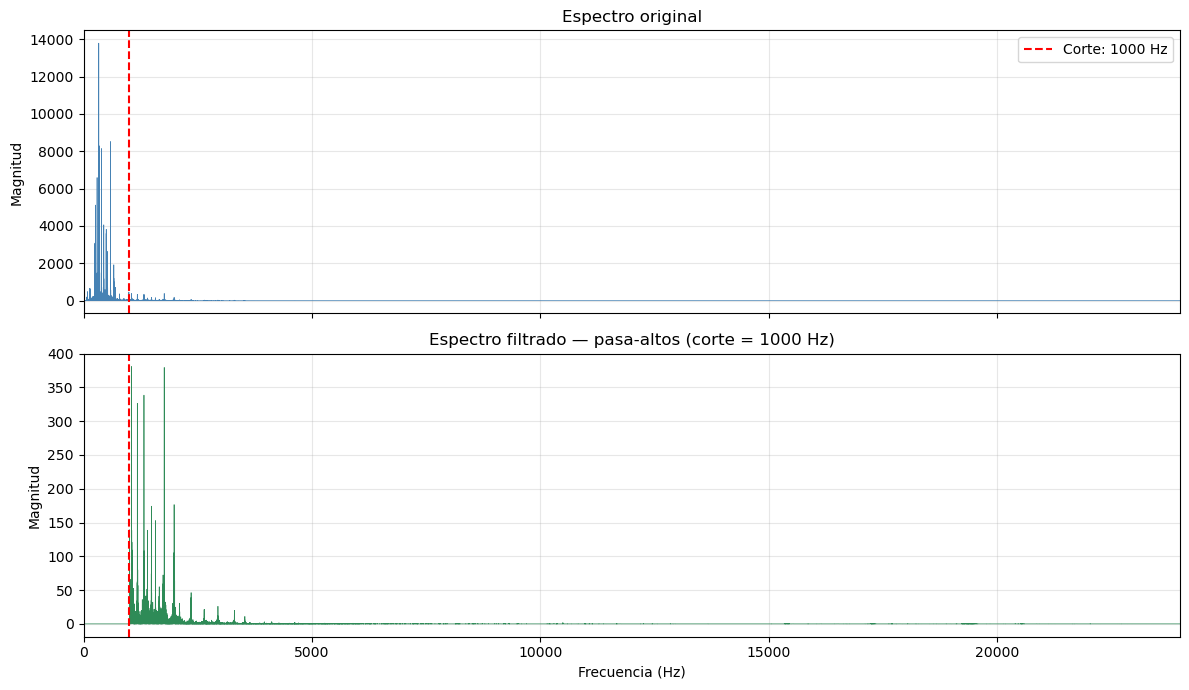

In [41]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

axes[0].plot(freqs, magnitud, linewidth=0.5, color='steelblue')
axes[0].axvline(f_corte_alto, color='red', linestyle='--', label=f'Corte: {f_corte_alto} Hz')
axes[0].set_ylabel('Magnitud')
axes[0].set_title('Espectro original')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(freqs, np.abs(fft_alto), linewidth=0.5, color='seagreen')
axes[1].axvline(f_corte_alto, color='red', linestyle='--')
axes[1].set_xlabel('Frecuencia (Hz)')
axes[1].set_ylabel('Magnitud')
axes[1].set_title(f'Espectro filtrado — pasa-altos (corte = {f_corte_alto} Hz)')
axes[1].grid(True, alpha=0.3)

plt.xlim(0, sample_rate // 2)
plt.tight_layout()
plt.show()

In [42]:
audio_alto = np.fft.irfft(fft_alto, n=N)

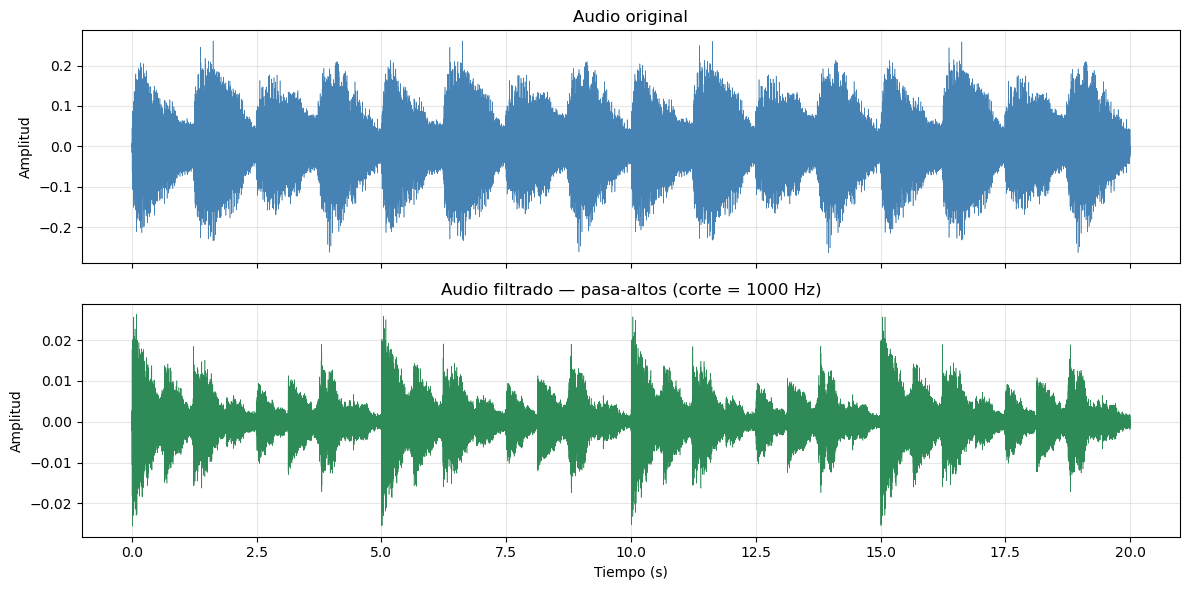

In [43]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

axes[0].plot(tiempo, audio, linewidth=0.4, color='steelblue')
axes[0].set_ylabel('Amplitud')
axes[0].set_title('Audio original')
axes[0].grid(True, alpha=0.3)

axes[1].plot(tiempo, audio_alto, linewidth=0.4, color='seagreen')
axes[1].set_xlabel('Tiempo (s)')
axes[1].set_ylabel('Amplitud')
axes[1].set_title(f'Audio filtrado — pasa-altos (corte = {f_corte_alto} Hz)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [44]:
wavfile.write('audio_pasa_altos.wav', sample_rate,
              np.int16(np.clip(audio_alto, -1, 1) * 32767))
print("Guardado: audio_pasa_altos.wav")

Guardado: audio_pasa_altos.wav


---
## Filtro 3: Eliminar las 3 frecuencias dominantes

Queremos encontrar las **3 frecuencias con mayor magnitud** y eliminar una banda alrededor de cada una.

El truco es hacerlo **en iteraciones**, para no confundir armónicos cercanos entre sí:

```
Iteración 1: buscar el máximo global → eliminar banda → guardar resultado
Iteración 2: buscar el máximo del espectro ya filtrado → eliminar banda → guardar resultado
Iteración 3: buscar el máximo del espectro ya filtrado → eliminar banda → guardar resultado
```

El ancho de la banda `ancho_banda` define cuántos Hz alrededor del máximo se eliminan.

In [48]:
ancho_banda = 10   # Hz a cada lado del máximo que se elimina
n_bandas    = 3    # cuántas frecuencias dominantes eliminar

# Partimos desde una copia limpia del espectro original
fft_bandas = fft_audio.copy()

# Guardamos los máximos encontrados para graficarlos después
maximos_eliminados = []

### Iteración 1: buscar el máximo y eliminar su banda

In [49]:
# Buscar la frecuencia con mayor magnitud en el espectro actual
idx_max = np.argmax(np.abs(fft_bandas))
f_max   = freqs[idx_max]
maximos_eliminados.append(f_max)
print(f"Iteración 1 — máximo en {f_max:.1f} Hz")

# Eliminar la banda [f_max - ancho_banda, f_max + ancho_banda]
mascara = np.abs(freqs - f_max) < ancho_banda
fft_bandas[mascara] = 0
print(f"  → eliminados {np.sum(mascara)} coeficientes")

Iteración 1 — máximo en 330.4 Hz
  → eliminados 399 coeficientes


AttributeError: 'Axes' object has no attribute 'ax'

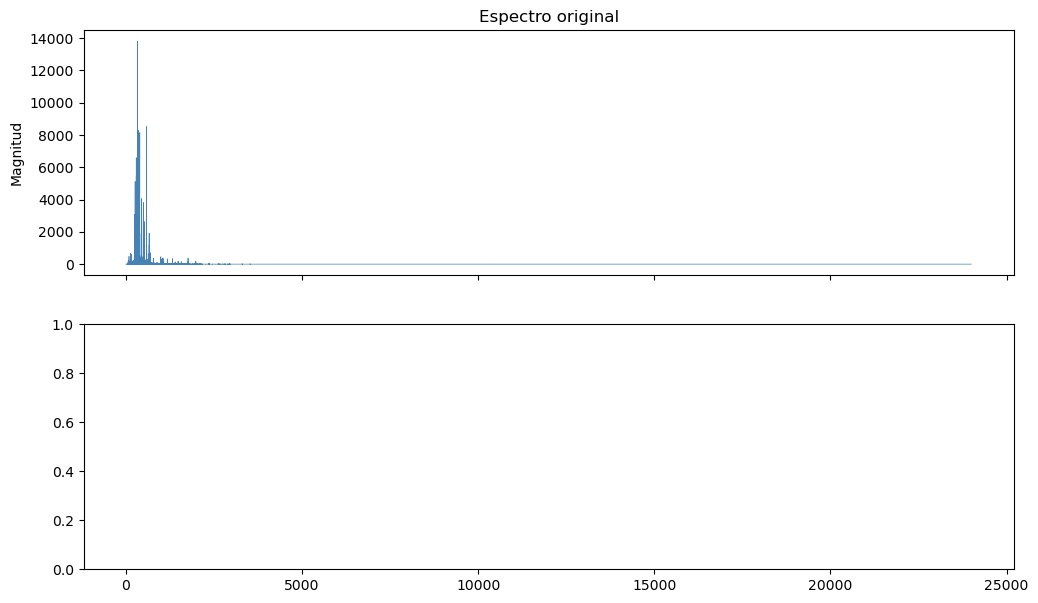

In [53]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

axes[0].plot(freqs, magnitud, linewidth=0.5, color='steelblue')
#axes[0].axvline(maximos_eliminados[0], color='red', linestyle='--',
 #               label=f'Máximo 1: {maximos_eliminados[0]:.1f} Hz')
axes[0].set_ylabel('Magnitud')
axes[0].set_title('Espectro original')
axes[0].ax.ylim([0, np.max(np.abs(fft_bandas))])
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(freqs, np.abs(fft_bandas), linewidth=0.5, color='mediumpurple')
#axes[1].axvline(maximos_eliminados[0], color='red', linestyle='--')
axes[1].set_xlabel('Frecuencia (Hz)')
axes[1].set_ylabel('Magnitud')
axes[1].set_title(f'Espectro tras eliminar banda en {maximos_eliminados[0]:.1f} Hz (±{ancho_banda} Hz)')
axes[1].grid(True, alpha=0.3)

plt.xlim(0, 4000)
plt.tight_layout()
plt.show()

### Iteración 2: buscar el nuevo máximo en el espectro ya filtrado

In [22]:
# Ahora el máximo se busca sobre el espectro que ya tiene la banda 1 eliminada
idx_max = np.argmax(np.abs(fft_bandas))
f_max   = freqs[idx_max]
maximos_eliminados.append(f_max)
print(f"Iteración 2 — máximo en {f_max:.1f} Hz")

mascara = np.abs(freqs - f_max) < ancho_banda
fft_bandas[mascara] = 0
print(f"  → eliminados {np.sum(mascara)} coeficientes")

Iteración 2 — máximo en 588.0 Hz
  → eliminados 1999 coeficientes


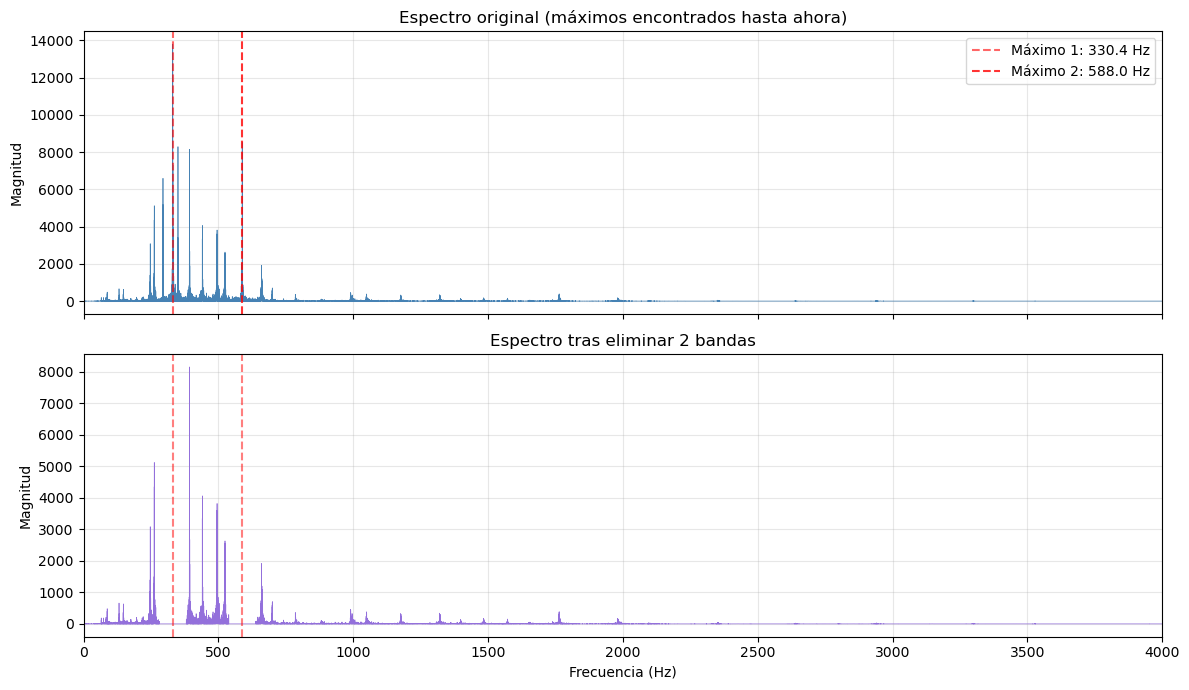

In [23]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

axes[0].plot(freqs, magnitud, linewidth=0.5, color='steelblue')
for i, fm in enumerate(maximos_eliminados):
    axes[0].axvline(fm, color='red', linestyle='--', alpha=0.6 + 0.2*i,
                    label=f'Máximo {i+1}: {fm:.1f} Hz')
axes[0].set_ylabel('Magnitud')
axes[0].set_title('Espectro original (máximos encontrados hasta ahora)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(freqs, np.abs(fft_bandas), linewidth=0.5, color='mediumpurple')
for fm in maximos_eliminados:
    axes[1].axvline(fm, color='red', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Frecuencia (Hz)')
axes[1].set_ylabel('Magnitud')
axes[1].set_title('Espectro tras eliminar 2 bandas')
axes[1].grid(True, alpha=0.3)

plt.xlim(0, 4000)
plt.tight_layout()
plt.show()

### Iteración 3: buscar el nuevo máximo y eliminar la última banda

In [24]:
idx_max = np.argmax(np.abs(fft_bandas))
f_max   = freqs[idx_max]
maximos_eliminados.append(f_max)
print(f"Iteración 3 — máximo en {f_max:.1f} Hz")

mascara = np.abs(freqs - f_max) < ancho_banda
fft_bandas[mascara] = 0
print(f"  → eliminados {np.sum(mascara)} coeficientes")

print(f"\nFrecuencias eliminadas: {[f'{fm:.1f} Hz' for fm in maximos_eliminados]}")

Iteración 3 — máximo en 392.6 Hz
  → eliminados 1999 coeficientes

Frecuencias eliminadas: ['330.4 Hz', '588.0 Hz', '392.6 Hz']


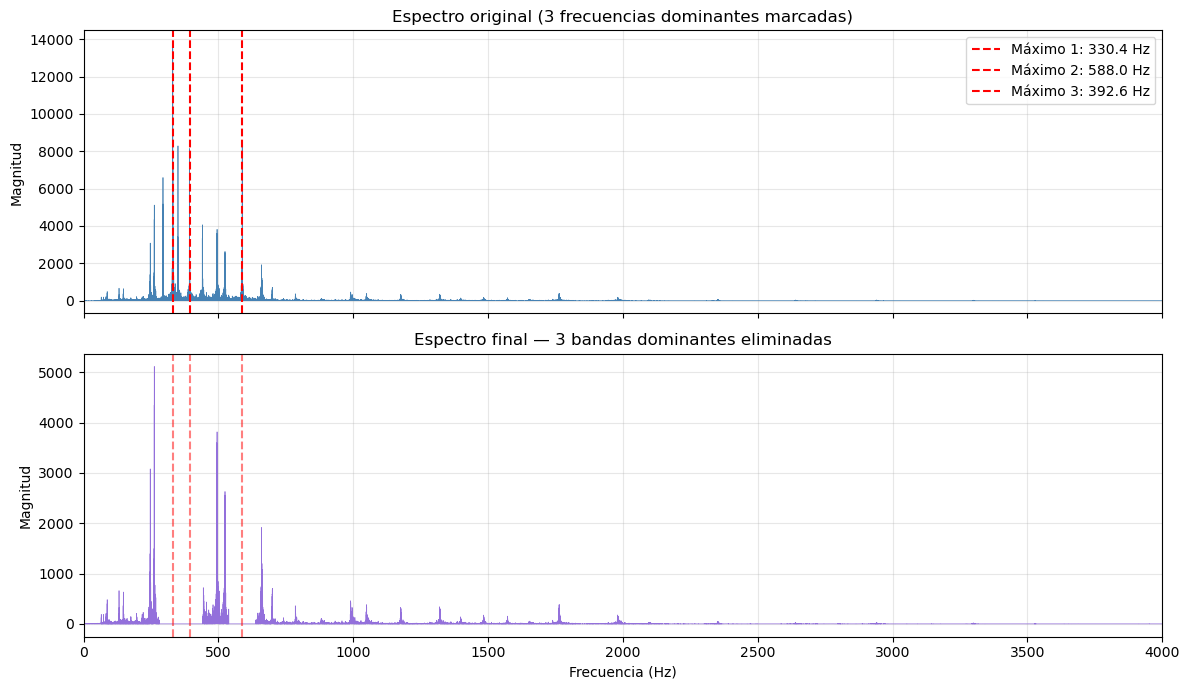

In [25]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

axes[0].plot(freqs, magnitud, linewidth=0.5, color='steelblue')
for i, fm in enumerate(maximos_eliminados):
    axes[0].axvline(fm, color='red', linestyle='--',
                    label=f'Máximo {i+1}: {fm:.1f} Hz')
axes[0].set_ylabel('Magnitud')
axes[0].set_title('Espectro original (3 frecuencias dominantes marcadas)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(freqs, np.abs(fft_bandas), linewidth=0.5, color='mediumpurple')
for fm in maximos_eliminados:
    axes[1].axvline(fm, color='red', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Frecuencia (Hz)')
axes[1].set_ylabel('Magnitud')
axes[1].set_title('Espectro final — 3 bandas dominantes eliminadas')
axes[1].grid(True, alpha=0.3)

plt.xlim(0, 4000)
plt.tight_layout()
plt.show()

In [26]:
audio_bandas = np.fft.irfft(fft_bandas, n=N)

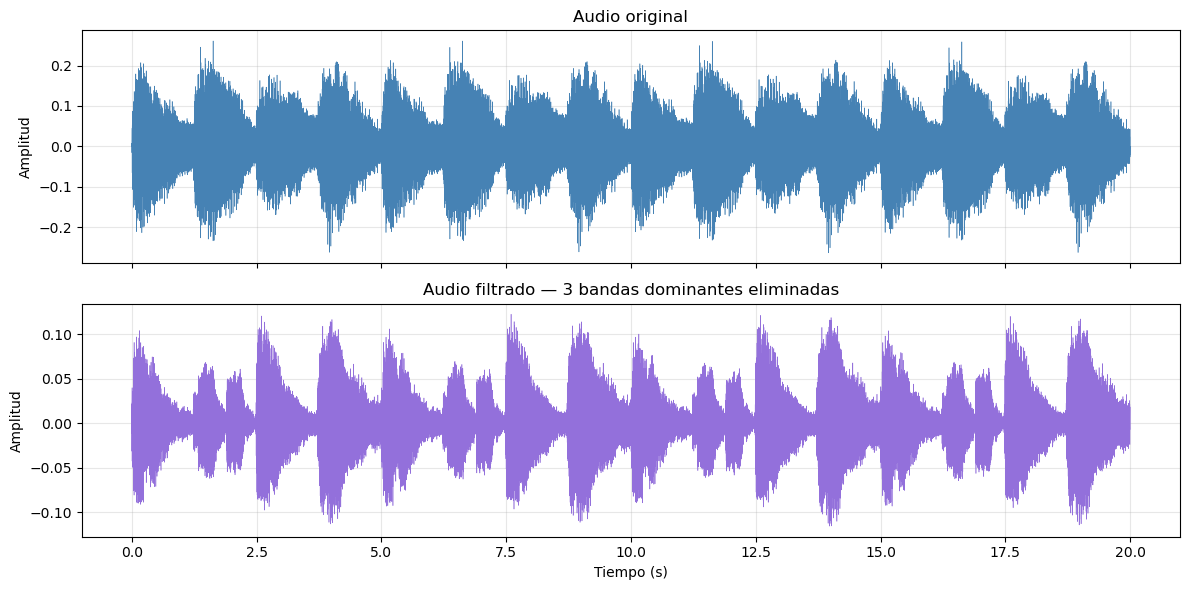

In [27]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

axes[0].plot(tiempo, audio, linewidth=0.4, color='steelblue')
axes[0].set_ylabel('Amplitud')
axes[0].set_title('Audio original')
axes[0].grid(True, alpha=0.3)

axes[1].plot(tiempo, audio_bandas, linewidth=0.4, color='mediumpurple')
axes[1].set_xlabel('Tiempo (s)')
axes[1].set_ylabel('Amplitud')
axes[1].set_title('Audio filtrado — 3 bandas dominantes eliminadas')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [28]:
wavfile.write('audio_bandas_eliminadas.wav', sample_rate,
              np.int16(np.clip(audio_bandas, -1, 1) * 32767))
print("Guardado: audio_bandas_eliminadas.wav")

Guardado: audio_bandas_eliminadas.wav


---
## Resumen

| Filtro | Qué elimina | Efecto esperado |
|---|---|---|
| Pasa-bajos | Frecuencias > 1000 Hz | Sonido apagado, sin agudos |
| Pasa-altos | Frecuencias < 3000 Hz | Sonido metálico, sin voz ni bajo |
| Bandas dominantes | Las 3 frecuencias con mayor magnitud (±50 Hz) | Se "sacan" las notas más fuertes |

En los tres casos el flujo es idéntico:

```
fft_audio.copy()  →  poner en cero ciertos coeficientes  →  irfft  →  guardar
```